# Orbit 971 — Agricultural Change Monitoring
**14 main numbered code cells + optional Codes 03B and 03C · 27 km2 · 2025**

ابدأ من Code 01 وشغّل الخلايا بالترتيب. لا تشغّل الكل مرة واحدة. إذا ظهر خطأ، توقف وأرسل رقم الكود والخطأ.
Run Code 01–06 first. Inspect Code 06, then continue to the image preview in Code 08.
These code cells are a packaged version of the numbered workflow in our conversation. The full satellite pipeline has **not been executed or field-validated here**.

**Purpose:** map vegetation changes that may warrant field inspection.
**Not established:** date-palm identification, water-stress diagnosis, early detection, irrigation amounts, or water savings.
The rectangle is not a verified farm boundary. The 20-metre pixels may mix vegetation, soil and structures.
Source: Copernicus Sentinel-2 L2A via Microsoft Planetary Computer.
Dates and thresholds below are exploratory, not calibrated crop limits.

**Checkpoints:** Code 06 selected scenes; Code 08 RGB image; Code 09 vegetation mask; Code 10 trends; Code 12 inspection flags.

### Updated area and data scope
The analysis rectangle is **5.4 km x 5 km = 27 km2**, centred on the original coordinates, measured on the UTM grid. It is an area to investigate, not 27 km2 of confirmed crops.
Codes 01–14 analyse Sentinel-2. Optional Code 03B inventories Landsat 8/9 candidates; it does not yet use temperature data in the analysis. Keep thermal resolution, date matching, bare-soil effects and cloud quality in mind before integration.
**After this area change, restart the runtime and rerun the numbered cells from Code 01. Previous small-area results must not be combined with these results.**

**EnMAP update:** Optional Code 03C discovers hyperspectral L2A candidates and overlap over the same area. Discovery is not a completed hyperspectral analysis. Only Sentinel-2 feeds the current results.


## Code 01 — Install project dependencies

In [2]:
# CODE 01 — Install project dependencies

%pip install -q pystac-client planetary-computer rasterio scipy pandas matplotlib requests shapely
print("Code 01 complete: tools installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.5 MB/s eta 0:00:00
Code 01 complete: tools installed.


## Code 02 — Project configuration

In [3]:
# CODE 02 — Project configuration

from pathlib import Path
import json
import math
import warnings
import shutil
import importlib.metadata
import xml.etree.ElementTree as ET

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.transform import from_origin
from rasterio.warp import transform_bounds
from scipy.ndimage import binary_dilation
from pystac_client import Client
import planetary_computer

PROJECT = "Orbit 971 — Agricultural Change Monitoring"
LATITUDE = 24.730353
LONGITUDE = 54.982294
AREA_WIDTH_M = 5400
AREA_HEIGHT_M = 5000
START_DATE = "2025-01-01"
END_DATE = "2025-12-31"
MAX_SCENE_CLOUD = 20
MIN_CLEAR_FRACTION = 0.80
RESOLUTION_M = 20

# Exploratory thresholds, not calibrated stress limits.
VEGETATION_NDVI = 0.30
MIN_OBSERVATIONS = 6
NDVI_DROP = 0.10
NDMI_DROP = 0.10

# Define the area in metres: 5.4 km x 5 km = 27 km2.
# BBOX is only a geographic envelope for catalogue searches.
# The exact analysis grid is defined in Code 04.
utm_zone = int((LONGITUDE + 180) // 6) + 1
epsg = (32600 if LATITUDE >= 0 else 32700) + utm_zone
GRID_CRS = f"EPSG:{epsg}"
centre_x, centre_y = rasterio.warp.transform(
    "EPSG:4326", GRID_CRS, [LONGITUDE], [LATITUDE]
)
left = centre_x[0] - AREA_WIDTH_M / 2
right = centre_x[0] + AREA_WIDTH_M / 2
bottom = centre_y[0] - AREA_HEIGHT_M / 2
top = centre_y[0] + AREA_HEIGHT_M / 2
BBOX = list(transform_bounds(
    GRID_CRS, "EPSG:4326", left, bottom, right, top, densify_pts=21
))
OUTPUT = Path("/content/orbit971_results_27km2")
OUTPUT.mkdir(parents=True, exist_ok=True)
print(PROJECT)
print("Search boundary:", BBOX)
print("Study period:", START_DATE, "to", END_DATE)
print("Output directory:", OUTPUT)
print("Analysis rectangle:", AREA_WIDTH_M / 1000, "km x", AREA_HEIGHT_M / 1000, "km")
print("Projected analysis area:", AREA_WIDTH_M * AREA_HEIGHT_M / 1e6, "km2")


Orbit 971 — Agricultural Change Monitoring
Search boundary: [54.95524311388864, 24.707427308892573, 55.00933534540102, 24.753274616945102]
Study period: 2025-01-01 to 2025-12-31
Output directory: /content/orbit971_results_27km2
Analysis rectangle: 5.4 km x 5.0 km
Projected analysis area: 27.0 km2


## Code 03 — Find Sentinel-2 scenes

In [4]:
# CODE 03 — Find Sentinel-2 scenes

catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=BBOX,
    datetime=f"{START_DATE}/{END_DATE}",
    query={"eo:cloud_cover": {"lt": MAX_SCENE_CLOUD}},
)
items = list({item.id: item for item in search.items()}.values())
items.sort(key=lambda item: item.datetime)
if not items:
    raise RuntimeError("No scenes found. Review the location or search filters.")

scene_table = pd.DataFrame([
    {
        "item_id": item.id,
        "date": item.datetime.strftime("%Y-%m-%d"),
        "scene_cloud_percent": item.properties.get("eo:cloud_cover"),
        "processing_baseline": item.properties.get("s2:processing_baseline"),
    }
    for item in items
])
scene_table.to_csv(OUTPUT / "catalogue_results.csv", index=False)
print("Catalogue records:", len(items))
print("Unique dates:", scene_table["date"].nunique())
display(scene_table.head(10))

Catalogue records: 132
Unique dates: 64


,item_id,date,scene_cloud_percent,processing_baseline
0,S2A_MSIL2A_20250112T065241_R020_T40RBN_2025011...,2025-01-12,0.213731,05.11
1,S2A_MSIL2A_20250112T065241_R020_T39RZH_2025011...,2025-01-12,0.233348,05.11
2,S2B_MSIL2A_20250127T065039_R020_T40RBN_2025012...,2025-01-27,0.373644,05.11
3,S2B_MSIL2A_20250127T065039_R020_T39RZH_2025012...,2025-01-27,0.515405,05.11
4,S2C_MSIL2A_20250201T065141_R020_T40RBN_2025020...,2025-02-01,0.466649,05.11
5,S2C_MSIL2A_20250201T065141_R020_T39RZH_2025020...,2025-02-01,0.518750,05.11
6,S2B_MSIL2A_20250206T064949_R020_T40RBN_2025020...,2025-02-06,8.263032,05.11
7,S2B_MSIL2A_20250206T064949_R020_T39RZH_2025020...,2025-02-06,8.756207,05.11
8,S2C_MSIL2A_20250211T065041_R020_T40RBN_2025021...,2025-02-11,6.713464,05.11
9,S2C_MSIL2A_20250211T065041_R020_T39RZH_2025021...,2025-02-11,6.044870,05.11


## Code 03B — Optional Landsat 8/9 availability check
Additional cell; Codes 01–14 keep their original numbers. Landsat may add surface-temperature evidence, but this cell only inventories candidate products. Actual thermal coverage, date matching and quality must be checked before integration. You may skip this optional cell and continue with Code 04.


In [5]:
# CODE 03B — Optional Landsat 8/9 availability check
# This inventories candidate thermal products only.
# It does NOT download temperature pixels or add them to our analysis.

landsat_search = catalog.search(
    collections=["landsat-c2-l2"],
    bbox=BBOX,
    datetime=f"{START_DATE}/{END_DATE}",
    query={"eo:cloud_cover": {"lt": MAX_SCENE_CLOUD}},
)
landsat_items = []
for candidate in landsat_search.items():
    platform = str(candidate.properties.get("platform", "")).lower().replace("_", "-")
    if platform in ["landsat-8", "landsat-9"]:
        landsat_items.append(candidate)
landsat_items = list({item.id: item for item in landsat_items}.values())
landsat_items.sort(key=lambda item: item.datetime)
landsat_rows = []
for item in landsat_items:
    landsat_rows.append({
        "item_id": item.id,
        "date": item.datetime.strftime("%Y-%m-%d"),
        "platform": item.properties.get("platform"),
        "scene_cloud_percent": item.properties.get("eo:cloud_cover"),
        "processing_level": item.properties.get("landsat:processing_level", "unknown"),
        "thermal_asset_listed": "lwir11" in item.assets,
    })
landsat_inventory = pd.DataFrame(landsat_rows, columns=[
    "item_id", "date", "platform", "scene_cloud_percent",
    "processing_level", "thermal_asset_listed",
])
landsat_inventory.to_csv(OUTPUT / "landsat_availability_only.csv", index=False)
print("Landsat candidate records:", len(landsat_inventory))
display(landsat_inventory.head(15))
print("Candidate metadata only. Local thermal coverage and quality are not verified.")
if not landsat_inventory.empty:
    print(landsat_inventory.groupby("platform").size())


Landsat candidate records: 36


,item_id,date,platform,scene_cloud_percent,processing_level,thermal_asset_listed
0,LC09_L2SP_160043_20250116_02_T1,2025-01-16,landsat-9,11.94,unknown,True
1,LC08_L2SP_160043_20250124_02_T1,2025-01-24,landsat-8,2.49,unknown,True
2,LC09_L2SP_160043_20250201_02_T1,2025-02-01,landsat-9,2.58,unknown,True
3,LC09_L2SP_160043_20250321_02_T1,2025-03-21,landsat-9,0.19,unknown,True
4,LC08_L2SP_160043_20250329_02_T1,2025-03-29,landsat-8,0.18,unknown,True
5,LC09_L2SP_160043_20250406_02_T1,2025-04-06,landsat-9,0.18,unknown,True
6,LC08_L2SP_160043_20250414_02_T1,2025-04-14,landsat-8,0.00,unknown,True
7,LC09_L2SP_160043_20250422_02_T1,2025-04-22,landsat-9,0.04,unknown,True
8,LC08_L2SP_160043_20250430_02_T1,2025-04-30,landsat-8,0.00,unknown,True
9,LC09_L2SP_160043_20250508_02_T1,2025-05-08,landsat-9,0.00,unknown,True


Candidate metadata only. Local thermal coverage and quality are not verified.
platform
landsat-8    17
landsat-9    19
dtype: int64


## Code 03C — EnMAP hyperspectral data discovery
**New hyperspectral source: EnMAP, official DLR L2A archive (224 bands).** Searches the same 27-km2 area and 2025 period, checks footprint intersection, and exports product/asset metadata.
**Discovery only:** no hyperspectral pixels are analysed yet. Downloading EnMAP data requires a registered account and licence acceptance. Do not share credentials in this notebook or chat.
If a search fails, report the error; a failed request is not evidence of no coverage. You can skip this optional cell and continue Sentinel-2 processing.
After successful discovery, send the resulting coverage table. The next integration step is access, quality masks, wavelength/calibration inspection and date-matched comparison.
[DLR L2A collection](https://geoservice.dlr.de/eoc/ogc/stac/v1/collections/ENMAP_HSI_L2A?f=text/html) · [EnMAP data access](https://enmap-box.readthedocs.io/en/latest/general/data_access.html)


In [6]:
# CODE 03C — EnMAP hyperspectral coverage and product discovery
# Uses the official DLR L2A catalogue (224 spectral bands).
# This does not download imagery or count EnMAP as analysed data.
# Downloads require an approved EnMAP account and licence acceptance.

from urllib.parse import urljoin
from shapely.geometry import shape, box

ENMAP_BASE = "https://geoservice.dlr.de/eoc/ogc/stac/v1"
ENMAP_COLLECTION = "ENMAP_HSI_L2A"
enmap_items = []
enmap_status = {
    "mission": "EnMAP",
    "collection": ENMAP_COLLECTION,
    "status": "search_started",
    "pixels_downloaded": False,
    "used_in_analysis": False,
    "period": [START_DATE, END_DATE],
    "search_bbox": BBOX,
    "projected_area_km2": AREA_WIDTH_M * AREA_HEIGHT_M / 1e6,
}

def save_enmap_status():
    with open(OUTPUT / "enmap_status.json", "w") as file:
        json.dump(enmap_status, file, indent=2, default=str)

try:
    session = requests.Session()
    response = session.get(
        f"{ENMAP_BASE}/collections/{ENMAP_COLLECTION}",
        headers={"Accept": "application/json"}, timeout=(15, 60),
    )
    response.raise_for_status()
    enmap_collection = response.json()
    enmap_status["licence"] = enmap_collection.get("license", "See provider terms")
    enmap_status["licence_links"] = [
        link["href"] for link in enmap_collection.get("links", [])
        if link.get("rel") == "license"
    ]
    url = f"{ENMAP_BASE}/collections/{ENMAP_COLLECTION}/items"
    params = {
        "bbox": ",".join(map(str, BBOX)),
        "datetime": f"{START_DATE}T00:00:00Z/{END_DATE}T23:59:59Z",
        "limit": 100,
    }
    features_by_id = {}
    visited = set()
    for page_number in range(100):
        response = session.get(
            url, params=params,
            headers={"Accept": "application/geo+json, application/json"},
            timeout=(15, 60),
        )
        response.raise_for_status()
        if response.url in visited:
            raise RuntimeError("Catalogue pagination repeated a page.")
        visited.add(response.url)
        page = response.json()
        if "features" not in page:
            raise RuntimeError("Catalogue did not return a feature collection.")
        for feature in page["features"]:
            features_by_id[feature["id"]] = feature
        next_links = [
            link for link in page.get("links", [])
            if link.get("rel") == "next"
        ]
        if not next_links:
            break
        if next_links[0].get("method", "GET").upper() != "GET":
            raise RuntimeError("Unexpected pagination method; review API response.")
        url = urljoin(response.url, next_links[0]["href"])
        params = None
    else:
        raise RuntimeError("Pagination limit reached; inventory is incomplete.")

    area_polygon = box(left, bottom, right, top)
    study_start = pd.Timestamp(START_DATE, tz="UTC")
    study_end = pd.Timestamp(END_DATE, tz="UTC") + pd.Timedelta(days=1)
    rows = []
    asset_rows = []
    for feature in features_by_id.values():
        props = feature.get("properties", {})
        raw_date = props.get("datetime") or props.get("start_datetime")
        if raw_date is None or feature.get("geometry") is None:
            raise RuntimeError("An EnMAP record has missing time or geometry; review it.")
        date = pd.to_datetime(raw_date, utc=True)
        if not (study_start <= date < study_end):
            continue
        footprint = shape(rasterio.warp.transform_geom(
            "EPSG:4326", GRID_CRS, feature["geometry"]
        ))
        if not footprint.is_valid:
            raise RuntimeError("Invalid EnMAP footprint; review its geometry.")
        overlap = footprint.intersection(area_polygon).area
        if overlap <= 0:
            continue
        enmap_items.append(feature)
        rows.append({
            "item_id": feature["id"],
            "date_utc": date.isoformat(),
            "footprint_overlap_percent": 100 * overlap / area_polygon.area,
            "scene_cloud_percent": props.get("eo:cloud_cover"),
            "overall_quality": props.get("enmap:overallQuality", "unknown"),
            "asset_count": len(feature.get("assets", {})),
        })
        for key, asset in feature.get("assets", {}).items():
            asset_rows.append({
                "item_id": feature["id"],
                "asset_key": key,
                "title": asset.get("title", ""),
                "media_type": asset.get("type", ""),
                "roles": ",".join(asset.get("roles", [])),
                "href": asset.get("href", ""),
            })

    enmap_inventory = pd.DataFrame(rows, columns=[
        "item_id", "date_utc", "footprint_overlap_percent",
        "scene_cloud_percent", "overall_quality", "asset_count",
    ]).sort_values("date_utc")
    enmap_inventory.to_csv(OUTPUT / "enmap_coverage_inventory.csv", index=False)
    pd.DataFrame(asset_rows, columns=[
        "item_id", "asset_key", "title", "media_type", "roles", "href",
    ]).to_csv(OUTPUT / "enmap_candidate_assets.csv", index=False)
    with open(OUTPUT / "enmap_candidate_metadata.geojson", "w") as file:
        json.dump({"type": "FeatureCollection", "features": enmap_items}, file)
    enmap_status["matching_records"] = len(enmap_items)
    enmap_status["status"] = (
        "candidates_found_not_downloaded" if enmap_items
        else "no_matching_records_in_this_catalogue_for_this_area_and_period"
    )
    save_enmap_status()
    print("EnMAP matching records:", len(enmap_items))
    if enmap_items:
        display(enmap_inventory)
        print("Footprint overlap is not a measure of cloud-free, usable coverage.")
        print("Overall quality: 0 = nominal; 1 = reduced; 2 = low; unknown = inspect metadata.")
        print("NEXT: review dates and quality, arrange authorised data access, then read the spectral data.")
    else:
        print("No matching L2A records returned for the 2025 study in this catalogue.")
        print("No substitute location or date was silently selected.")
    print("EnMAP is NOT yet included in the crop indices or inspection flags.")

except Exception as error:
    enmap_status["status"] = "search_failed_coverage_unknown"
    enmap_status["error"] = str(error)
    save_enmap_status()
    print("The EnMAP search failed. This does NOT mean there are no images.")
    raise


EnMAP matching records: 1


,item_id,date_utc,footprint_overlap_percent,scene_cloud_percent,overall_quality,asset_count
0,ENMAP01-____L2A-DT0000156574_20250927T073735Z_...,2025-09-27T07:37:37.638618+00:00,100.0,0,0,13


Footprint overlap is not a measure of cloud-free, usable coverage.
Overall quality: 0 = nominal; 1 = reduced; 2 = low; unknown = inspect metadata.
NEXT: review dates and quality, arrange authorised data access, then read the spectral data.
EnMAP is NOT yet included in the crop indices or inspection flags.


## Code 04 — Create a common 20-metre grid

In [7]:
# CODE 04 — Create the exact 27-km2 analysis grid

assert AREA_WIDTH_M % RESOLUTION_M == 0
assert AREA_HEIGHT_M % RESOLUTION_M == 0
WIDTH = AREA_WIDTH_M // RESOLUTION_M
HEIGHT = AREA_HEIGHT_M // RESOLUTION_M
TRANSFORM = from_origin(left, top, RESOLUTION_M, RESOLUTION_M)
EXTENT = [left, right, bottom, top]
grid_area_km2 = WIDTH * HEIGHT * RESOLUTION_M**2 / 1e6
assert abs(grid_area_km2 - 27.0) < 1e-9
print("Map coordinate system:", GRID_CRS)
print("Grid:", WIDTH, "columns x", HEIGHT, "rows")
print("Pixel size:", RESOLUTION_M, "metres")
print("Analysis grid area:", grid_area_km2, "km2")


Map coordinate system: EPSG:32640
Grid: 270 columns x 250 rows
Pixel size: 20 metres
Analysis grid area: 27.0 km2


Code 05 defines functions only. Reflectance scaling and offsets are read from metadata; do not replace a calibration failure with guessed values.

## Code 05 — Read image bands and convert to reflectance

In [8]:
# CODE 05 — Read image bands and convert to reflectance

def read_grid(item, asset_key, categorical=False):
    """Read only the study grid from a remote image."""
    if asset_key not in item.assets:
        raise KeyError(f"{item.id}: missing asset {asset_key}")
    asset = planetary_computer.sign(item.assets[asset_key])
    method = Resampling.nearest if categorical else Resampling.average
    with rasterio.Env(
        GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
        GDAL_HTTP_MAX_RETRY=3,
        GDAL_HTTP_RETRY_DELAY=2,
    ):
        with rasterio.open(asset.href) as src:
            with WarpedVRT(
                src,
                crs=GRID_CRS,
                transform=TRANSFORM,
                width=WIDTH,
                height=HEIGHT,
                src_nodata=0,
                nodata=0,
                resampling=method,
            ) as vrt:
                data = vrt.read(1, masked=True)
                data = data.astype("float32").filled(np.nan)
    return data

calibration_cache = {}
BAND_ORDER = [
    "B01", "B02", "B03", "B04", "B05", "B06", "B07",
    "B08", "B8A", "B09", "B10", "B11", "B12",
]

def calibration_from_xml(item):
    """Read quantification and offsets from product metadata."""
    if item.id in calibration_cache:
        return calibration_cache[item.id]
    if "product-metadata" not in item.assets:
        raise RuntimeError(
            f"{item.id}: product metadata missing; do not guess scaling."
        )
    asset = planetary_computer.sign(item.assets["product-metadata"])
    response = requests.get(asset.href, timeout=60)
    response.raise_for_status()
    root = ET.fromstring(response.content)
    quantification = None
    offsets = {}
    for node in root.iter():
        tag = node.tag.split("}")[-1]
        if tag == "BOA_QUANTIFICATION_VALUE":
            quantification = float(node.text)
        elif tag == "BOA_ADD_OFFSET":
            band_id = int(node.attrib["band_id"])
            offsets[BAND_ORDER[band_id]] = float(node.text)
    if quantification is None or quantification <= 0:
        raise RuntimeError(f"{item.id}: cannot read BOA quantification.")
    if not offsets:
        baseline = item.properties.get("s2:processing_baseline")
        if baseline is None or float(baseline) >= 4:
            raise RuntimeError(f"{item.id}: reflectance offsets missing.")
        offsets = {band: 0.0 for band in BAND_ORDER}
    calibration_cache[item.id] = (quantification, offsets)
    return quantification, offsets

def read_reflectance(item, band):
    raw = read_grid(item, band)
    metadata = item.assets[band].extra_fields.get("raster:bands", [{}])[0]
    scale = metadata.get("scale")
    offset = metadata.get("offset")
    if (
        scale is not None and offset is not None
        and 0 < float(scale) < 0.01
    ):
        return raw * float(scale) + float(offset)
    quantification, offsets = calibration_from_xml(item)
    if band not in offsets:
        raise RuntimeError(f"No calibration offset for {band}")
    return (raw + offsets[band]) / quantification

def clear_pixels(item):
    """Exclude cloud, shadow, snow, invalid and uncertain pixels."""
    scl = read_grid(item, "SCL", categorical=True)
    clear = np.isin(scl, [4, 5, 6])
    suspect = np.isin(scl, [2, 3, 8, 9, 10, 11])
    clear &= ~binary_dilation(suspect, iterations=1)
    return clear

print("Code 05 complete: image-reading functions ready.")

Code 05 complete: image-reading functions ready.


Code 06 may take several minutes. It selects one snapshot per month, **not a monthly average**. Inspect missing months and failed reads before continuing.

## Code 06 — Screen local quality and select monthly scenes

In [9]:
# CODE 06 — Screen local quality and select monthly scenes

quality_rows = []
screening_failures = []
clear_cache = {}
item_lookup = {item.id: item for item in items}

for number, item in enumerate(items, start=1):
    try:
        clear = clear_pixels(item)
        clear_cache[item.id] = clear

        quality_rows.append({
            "item_id": item.id,
            "date": item.datetime.strftime("%Y-%m-%d"),
            "month": item.datetime.strftime("%Y-%m"),
            "clear_fraction": float(clear.mean()),
            "scene_cloud_percent": float(
                item.properties.get("eo:cloud_cover", 100)
            ),
        })

    except Exception as error:
        screening_failures.append({
            "item_id": item.id,
            "error": str(error),
        })

        print(
            "Could not screen:",
            item.id,
            type(error).__name__,
            str(error)[:300],
        )

    if number % 10 == 0 or number == len(items):
        print(f"Screened {number}/{len(items)} records")

if not quality_rows:
    raise RuntimeError(
        "All image reads failed. Stop and share the error output."
    )

quality = pd.DataFrame(quality_rows)
quality.to_csv(
    OUTPUT / "local_quality_checks.csv",
    index=False,
)

pd.DataFrame(screening_failures).to_csv(
    OUTPUT / "screening_failures.csv",
    index=False,
)

eligible = quality[
    quality["clear_fraction"] >= MIN_CLEAR_FRACTION
].copy()

if eligible.empty:
    raise RuntimeError(
        "No scene meets the local clear-coverage threshold. "
        "Review coverage."
    )

selected = (
    eligible.sort_values(
        ["month", "clear_fraction", "scene_cloud_percent", "date"],
        ascending=[True, False, True, True],
    )
    .drop_duplicates("month")
    .sort_values("date")
    .reset_index(drop=True)
)

selected.to_csv(
    OUTPUT / "selected_scenes.csv",
    index=False,
)

print("\nSelected months:", len(selected))
print("Screening failures:", len(screening_failures))
display(selected)

if len(selected) < MIN_OBSERVATIONS + 1:
    print(
        "WARNING: Code 12 needs at least",
        MIN_OBSERVATIONS + 1,
        "snapshots (six reference + one latest).",
    )

Screened 10/132 records
Screened 20/132 records
Screened 30/132 records
Screened 40/132 records
Screened 50/132 records
Screened 60/132 records
Screened 70/132 records
Screened 80/132 records
Screened 90/132 records
Screened 100/132 records
Screened 110/132 records
Screened 120/132 records
Screened 130/132 records
Screened 132/132 records

Selected months: 12
Screening failures: 0


,item_id,date,month,clear_fraction,scene_cloud_percent
0,S2A_MSIL2A_20250112T065241_R020_T40RBN_2025011...,2025-01-12,2025-01,1.0,0.213731
1,S2C_MSIL2A_20250201T065141_R020_T40RBN_2025020...,2025-02-01,2025-02,1.0,0.466649
2,S2B_MSIL2A_20250318T064629_R020_T40RBN_2025031...,2025-03-18,2025-03,1.0,0.205771
3,S2C_MSIL2A_20250412T064651_R020_T40RBN_2025041...,2025-04-12,2025-04,1.0,0.523026
4,S2C_MSIL2A_20250502T064651_R020_T40RBN_2025050...,2025-05-02,2025-05,1.0,0.383511
5,S2B_MSIL2A_20250616T064619_R020_T40RBN_2025061...,2025-06-16,2025-06,1.0,0.169606
6,S2C_MSIL2A_20250721T064651_R020_T40RBN_2025072...,2025-07-21,2025-07,1.0,2.552815
7,S2A_MSIL2A_20250812T065321_R020_T40RBN_2025081...,2025-08-12,2025-08,1.0,0.367527
8,S2B_MSIL2A_20250914T064619_R020_T40RBN_2025091...,2025-09-14,2025-09,1.0,0.330582
9,S2A_MSIL2A_20251031T065321_R020_T40RBN_2025103...,2025-10-31,2025-10,1.0,0.212717


**Checkpoint: send the Code 06 table before proceeding.** If any cell fails, stop; do not use partially calculated results.

## Code 07 — Calculate spectral indices

In [10]:
# CODE 07 — Calculate spectral indices

PROCESSING_COMPLETE = False
records = []
_pending_records = []

BANDS = [
    "B02", "B03", "B04", "B05",
    "B08", "B8A", "B11",
]


def normalized_difference(a, b):
    denominator = a + b

    result = np.full_like(
        a,
        np.nan,
        dtype="float32",
    )

    valid = (
        np.isfinite(a)
        & np.isfinite(b)
        & (a >= 0)
        & (b >= 0)
        & (denominator > 1e-6)
    )

    np.divide(
        a - b,
        denominator,
        out=result,
        where=valid,
    )

    return result


for row in selected.itertuples(index=False):
    item = item_lookup[row.item_id]
    print("Loading:", row.date, item.id)

    bands = {
        band: read_reflectance(item, band)
        for band in BANDS
    }

    valid = clear_cache[item.id].copy()

    for band in BANDS:
        valid &= np.isfinite(bands[band])
        valid &= bands[band] >= 0

    indices = {
        "NDVI": normalized_difference(
            bands["B08"], bands["B04"]
        ),
        "NDRE": normalized_difference(
            bands["B8A"], bands["B05"]
        ),
        "NDMI": normalized_difference(
            bands["B8A"], bands["B11"]
        ),
        "BSI": normalized_difference(
            bands["B11"] + bands["B04"],
            bands["B08"] + bands["B02"],
        ),
    }

    for name in indices:
        indices[name] = np.where(
            valid,
            indices[name],
            np.nan,
        ).astype("float32")

    rgb = np.stack(
        [bands["B04"], bands["B03"], bands["B02"]],
        axis=-1,
    )
    rgb[~valid] = np.nan

    _pending_records.append({
        "item_id": item.id,
        "date": row.date,
        "indices": indices,
        "rgb": rgb,
    })

if (
    not _pending_records
    or len(_pending_records) != len(selected)
):
    raise RuntimeError(
        "Processing incomplete. Do not run the following cells."
    )

records = _pending_records
PROCESSING_COMPLETE = True

print("Processed monthly snapshots:", len(records))

Loading: 2025-01-12 S2A_MSIL2A_20250112T065241_R020_T40RBN_20250112T101851
Loading: 2025-02-01 S2C_MSIL2A_20250201T065141_R020_T40RBN_20250201T104612
Loading: 2025-03-18 S2B_MSIL2A_20250318T064629_R020_T40RBN_20250318T092100
Loading: 2025-04-12 S2C_MSIL2A_20250412T064651_R020_T40RBN_20250412T121419
Loading: 2025-05-02 S2C_MSIL2A_20250502T064651_R020_T40RBN_20250502T113729
Loading: 2025-06-16 S2B_MSIL2A_20250616T064619_R020_T40RBN_20250616T090449
Loading: 2025-07-21 S2C_MSIL2A_20250721T064651_R020_T40RBN_20250721T120716
Loading: 2025-08-12 S2A_MSIL2A_20250812T065321_R020_T40RBN_20250812T093816
Loading: 2025-09-14 S2B_MSIL2A_20250914T064619_R020_T40RBN_20250914T090756
Loading: 2025-10-31 S2A_MSIL2A_20251031T065321_R020_T40RBN_20251031T093101
Loading: 2025-11-13 S2B_MSIL2A_20251113T065029_R020_T40RBN_20251113T085315
Loading: 2025-12-03 S2B_MSIL2A_20251203T065149_R020_T40RBN_20251203T084904
Processed monthly snapshots: 12


## Code 08 — Display a true-colour view of the study area

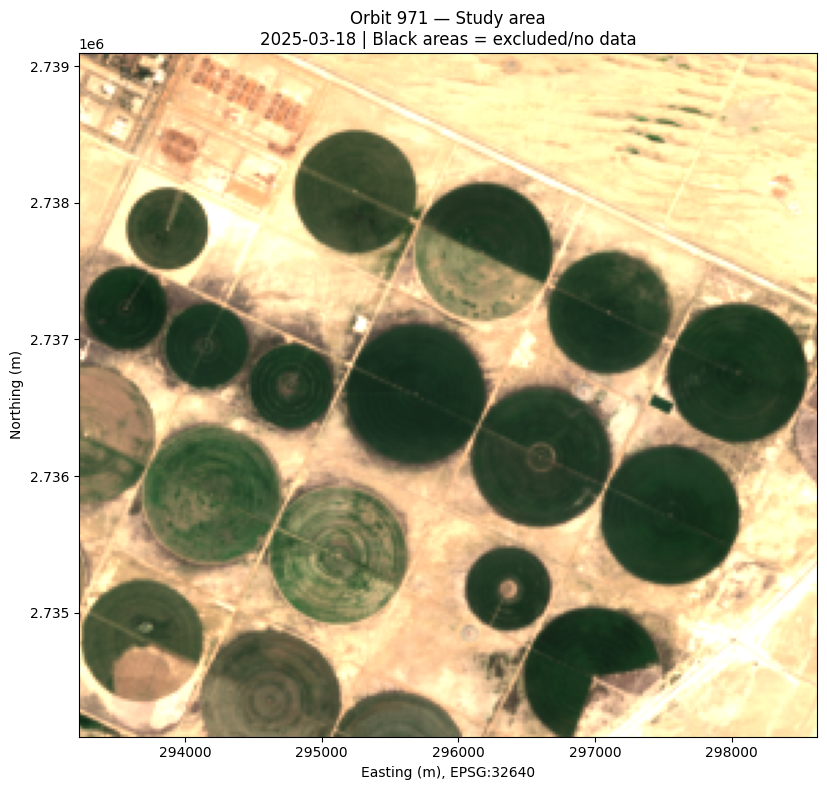

In [11]:
# CODE 08 — Display a true-colour view of the study area

assert globals().get("PROCESSING_COMPLETE", False), (
    "Code 07 did not finish successfully. "
    "Fix and rerun it before continuing."
)
preview = max(
    records,
    key=lambda record: np.isfinite(record["indices"]["NDVI"]).sum(),
)
rgb_display = np.clip(preview["rgb"] / 0.30, 0, 1)
rgb_display = np.nan_to_num(rgb_display, nan=0.0)
fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(rgb_display, extent=EXTENT)
ax.set_title(
    f"Orbit 971 — Study area\n"
    f"{preview['date']} | Black areas = excluded/no data"
)
ax.set_xlabel(f"Easting (m), {GRID_CRS}")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig(OUTPUT / "study_area_rgb.png", dpi=180)
plt.show()

**Checkpoint: confirm the intended farmland is visible.** Code 09's NDVI mask is not a farm boundary or a date-palm classifier. If available, upload a confirmed WGS84 longitude/latitude GeoJSON polygon and set FARM_GEOJSON.

## Code 09 — Define analysis pixels

Boundary: Search rectangle — farm boundary not verified
Qualifying vegetation pixels: 27128
Qualifying grid area, hectares: 1085.12


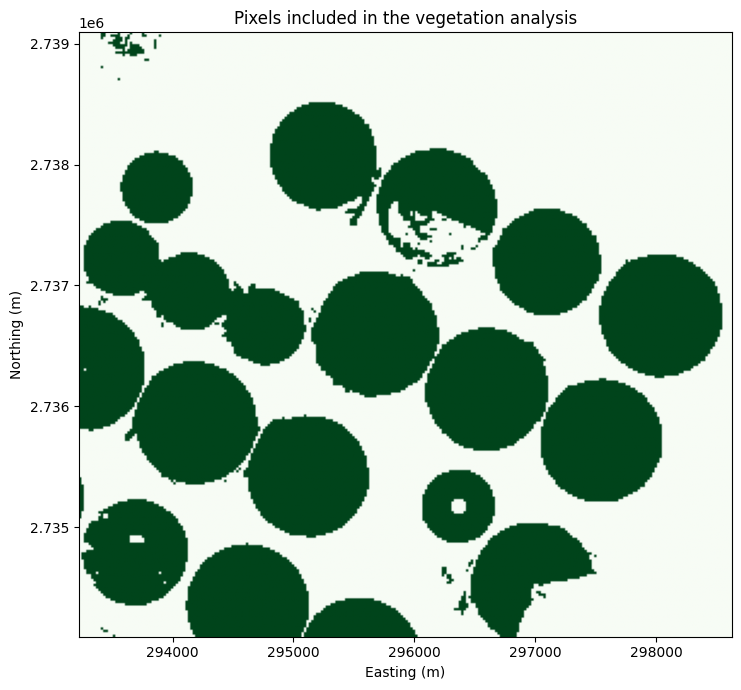

In [12]:
# CODE 09 — Define analysis pixels
assert globals().get("PROCESSING_COMPLETE", False), (
    "Code 07 did not finish successfully. "
    "Fix and rerun it before continuing."
)

from rasterio.features import geometry_mask
from rasterio.warp import transform_geom

FARM_GEOJSON = None
# Example: FARM_GEOJSON = "/content/farm_boundary.geojson"
analysis_mask = np.ones((HEIGHT, WIDTH), dtype=bool)
if FARM_GEOJSON is not None:
    with open(FARM_GEOJSON) as file:
        geojson = json.load(file)
    if geojson["type"] == "FeatureCollection":
        geometries = [feature["geometry"] for feature in geojson["features"]]
    elif geojson["type"] == "Feature":
        geometries = [geojson["geometry"]]
    else:
        geometries = [geojson]
    projected = [
        transform_geom("EPSG:4326", GRID_CRS, geometry)
        for geometry in geometries
    ]
    analysis_mask = geometry_mask(
        projected, out_shape=(HEIGHT, WIDTH),
        transform=TRANSFORM, invert=True,
    )
stacks = {
    name: np.stack([record["indices"][name] for record in records])
    for name in ["NDVI", "NDRE", "NDMI", "BSI"]
}
valid_count = np.isfinite(stacks["NDVI"]).sum(axis=0)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    median_ndvi = np.nanmedian(stacks["NDVI"], axis=0)
vegetation_mask = (
    analysis_mask & (median_ndvi >= VEGETATION_NDVI)
    & (valid_count >= MIN_OBSERVATIONS)
)
pixel_area_ha = RESOLUTION_M**2 / 10000
vegetation_area_ha = vegetation_mask.sum() * pixel_area_ha
print("Boundary:", "Uploaded farm polygon" if FARM_GEOJSON
      else "Search rectangle — farm boundary not verified")
print("Qualifying vegetation pixels:", vegetation_mask.sum())
print("Qualifying grid area, hectares:", round(vegetation_area_ha, 2))
if not vegetation_mask.any():
    raise RuntimeError(
        "No pixels meet vegetation/observation criteria. Inspect imagery."
    )
plt.figure(figsize=(8, 7))
plt.imshow(vegetation_mask, extent=EXTENT, cmap="Greens", vmin=0, vmax=1)
plt.title("Pixels included in the vegetation analysis")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.tight_layout()
plt.savefig(OUTPUT / "vegetation_mask.png", dpi=180)
plt.show()

## Code 10 — Compare the same vegetation pixels through time

,date,item_id,common_pixel_count,NDVI,NDRE,NDMI,BSI
0,2025-01-12,S2A_MSIL2A_20250112T065241_R020_T40RBN_2025011...,27099,0.690595,0.460153,0.159304,-0.086614
1,2025-02-01,S2C_MSIL2A_20250201T065141_R020_T40RBN_2025020...,27099,0.610166,0.371964,0.111180,-0.033513
2,2025-03-18,S2B_MSIL2A_20250318T064629_R020_T40RBN_2025031...,27099,0.750278,0.544447,0.247097,-0.197958
3,2025-04-12,S2C_MSIL2A_20250412T064651_R020_T40RBN_2025041...,27099,0.690107,0.439474,0.179201,-0.104254
4,2025-05-02,S2C_MSIL2A_20250502T064651_R020_T40RBN_2025050...,27099,0.644172,0.415320,0.158407,-0.076817
5,2025-06-16,S2B_MSIL2A_20250616T064619_R020_T40RBN_2025061...,27099,0.515466,0.373749,0.018133,0.038550
6,2025-07-21,S2C_MSIL2A_20250721T064651_R020_T40RBN_2025072...,27099,0.391607,0.283746,-0.072408,0.167213
7,2025-08-12,S2A_MSIL2A_20250812T065321_R020_T40RBN_2025081...,27099,0.495528,0.360121,0.000580,0.092330
8,2025-09-14,S2B_MSIL2A_20250914T064619_R020_T40RBN_2025091...,27099,0.529963,0.384303,-0.017972,0.106587
9,2025-10-31,S2A_MSIL2A_20251031T065321_R020_T40RBN_2025103...,27099,0.447723,0.321110,-0.054130,0.135441


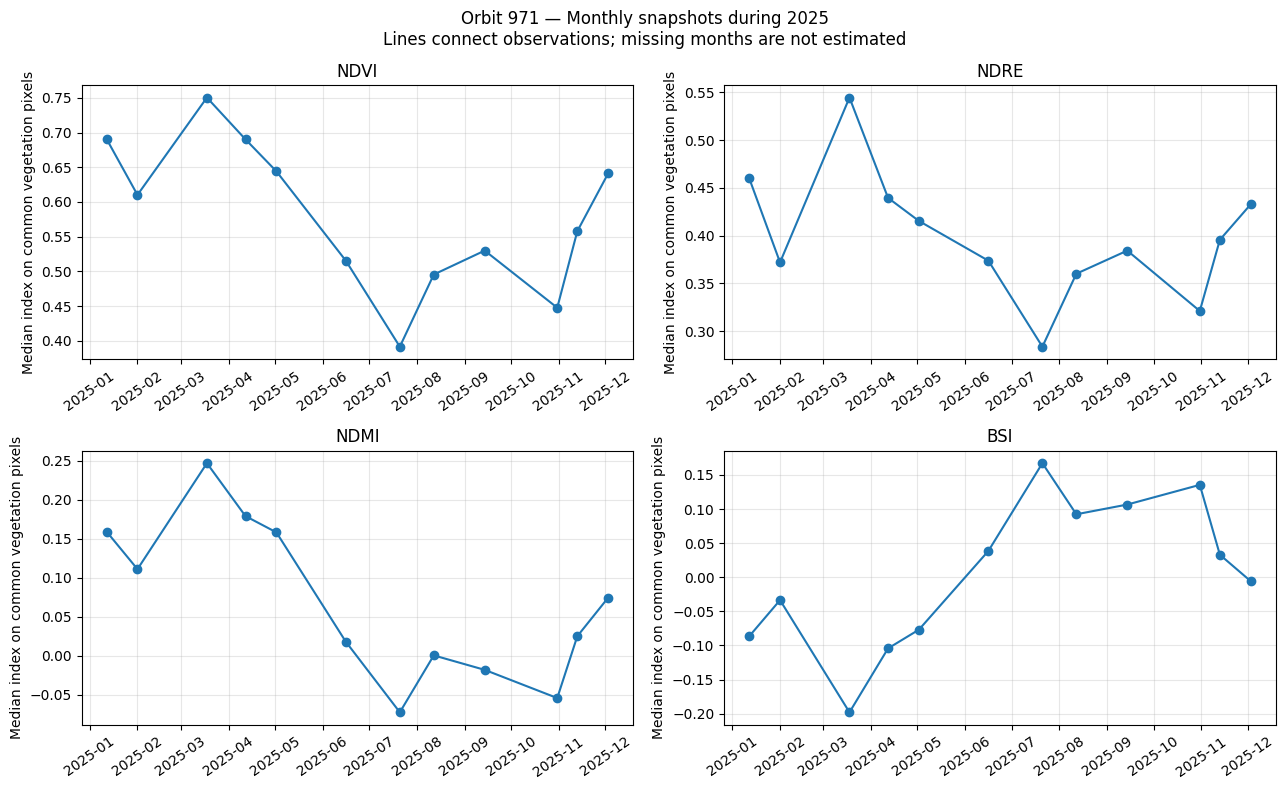

In [13]:
# CODE 10 — Compare the same vegetation pixels through time
assert globals().get("PROCESSING_COMPLETE", False), (
    "Code 07 did not finish successfully. "
    "Fix and rerun it before continuing."
)

common_mask = vegetation_mask.copy()
for name in stacks:
    common_mask &= np.all(np.isfinite(stacks[name]), axis=0)
if common_mask.sum() < 10:
    raise RuntimeError(
        "Fewer than 10 vegetation pixels are valid on every date. "
        "Review selected dates or boundary before interpreting trends."
    )
rows = []
for position, record in enumerate(records):
    row = {
        "date": record["date"],
        "item_id": record["item_id"],
        "common_pixel_count": int(common_mask.sum()),
    }
    for name in stacks:
        row[name] = float(np.median(stacks[name][position][common_mask]))
    rows.append(row)
summary = pd.DataFrame(rows)
summary.to_csv(OUTPUT / "vegetation_time_series.csv", index=False)
display(summary)
dates = pd.to_datetime(summary["date"])
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, name in zip(axes.flat, stacks):
    ax.plot(dates, summary[name], marker="o")
    ax.set_title(name)
    ax.set_ylabel("Median index on common vegetation pixels")
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=35)
fig.suptitle(
    "Orbit 971 — Monthly snapshots during 2025\n"
    "Lines connect observations; missing months are not estimated"
)
plt.tight_layout()
plt.savefig(OUTPUT / "index_time_series.png", dpi=180)
plt.show()

## Code 11 — Latest index maps

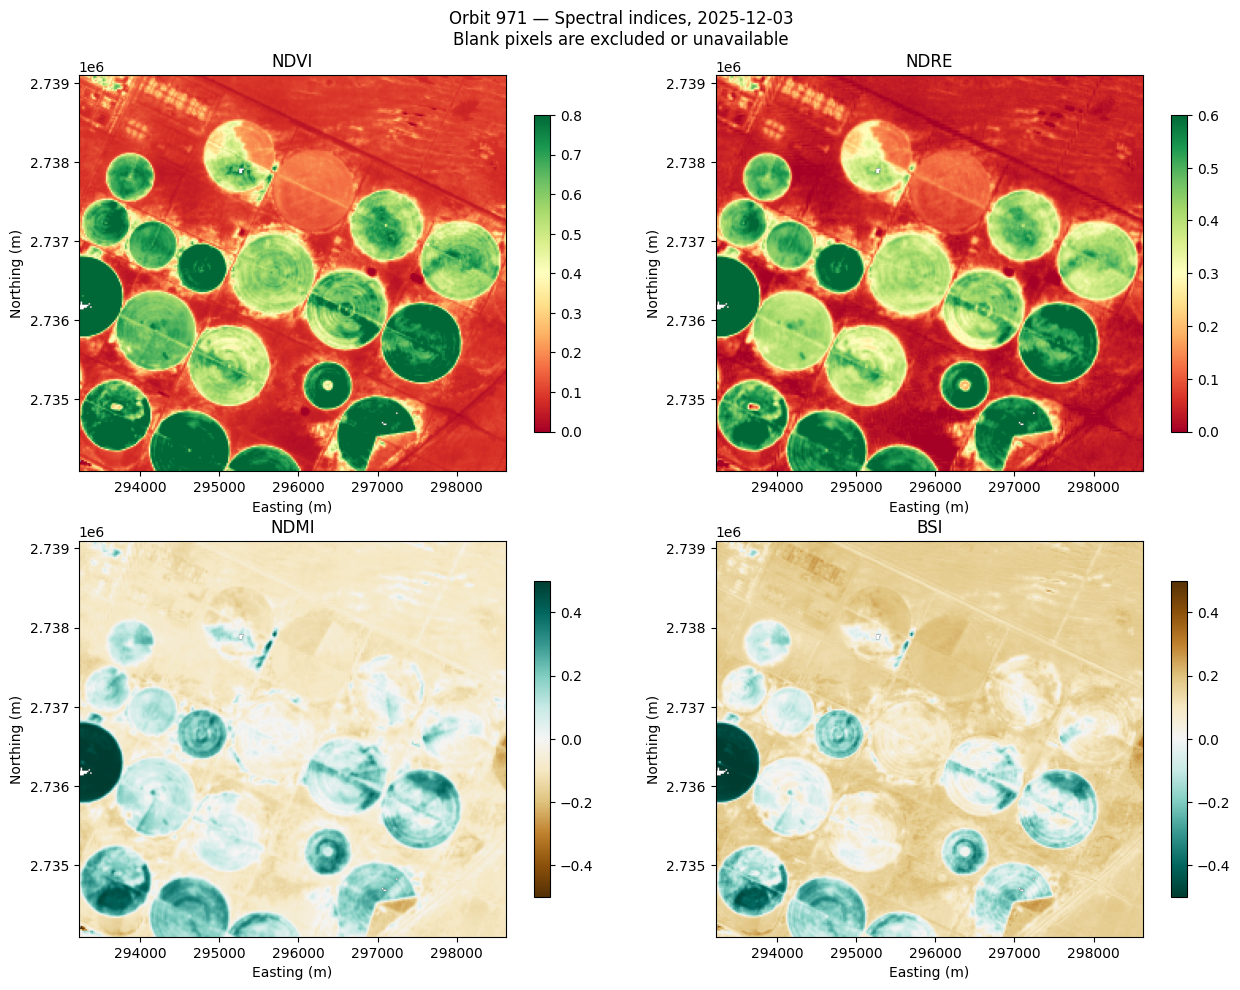

In [14]:
# CODE 11 — Latest index maps
assert globals().get("PROCESSING_COMPLETE", False), (
    "Code 07 did not finish successfully. "
    "Fix and rerun it before continuing."
)

latest = records[-1]
styles = {
    "NDVI": ("RdYlGn", 0.0, 0.8),
    "NDRE": ("RdYlGn", 0.0, 0.6),
    "NDMI": ("BrBG", -0.5, 0.5),
    "BSI": ("BrBG_r", -0.5, 0.5),
}
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, name in zip(axes.flat, stacks):
    cmap, minimum, maximum = styles[name]
    data = np.where(analysis_mask, latest["indices"][name], np.nan)
    image = ax.imshow(
        data, extent=EXTENT, cmap=cmap, vmin=minimum, vmax=maximum,
    )
    ax.set_title(name)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    fig.colorbar(image, ax=ax, shrink=0.8)
fig.suptitle(
    f"Orbit 971 — Spectral indices, {latest['date']}\n"
    "Blank pixels are excluded or unavailable"
)
plt.tight_layout()
plt.savefig(OUTPUT / "latest_index_maps.png", dpi=180)
plt.show()

The latest date means the latest selected **2025** snapshot, not live monitoring. Code 12 uses exploratory thresholds and a reference that is **not seasonally matched**. Joint declines can reflect seasonal or management changes; no joint flag does not prove healthy crops.

## Code 12 — Flag joint greenness and moisture-index declines

Latest snapshot: 2025-12-03
Assessed vegetation grid area: 1083.96 ha
Flagged grid area: 106.08 ha
Flagged share of assessed area: 9.8 %
Flags indicate change for inspection, not confirmed water stress.


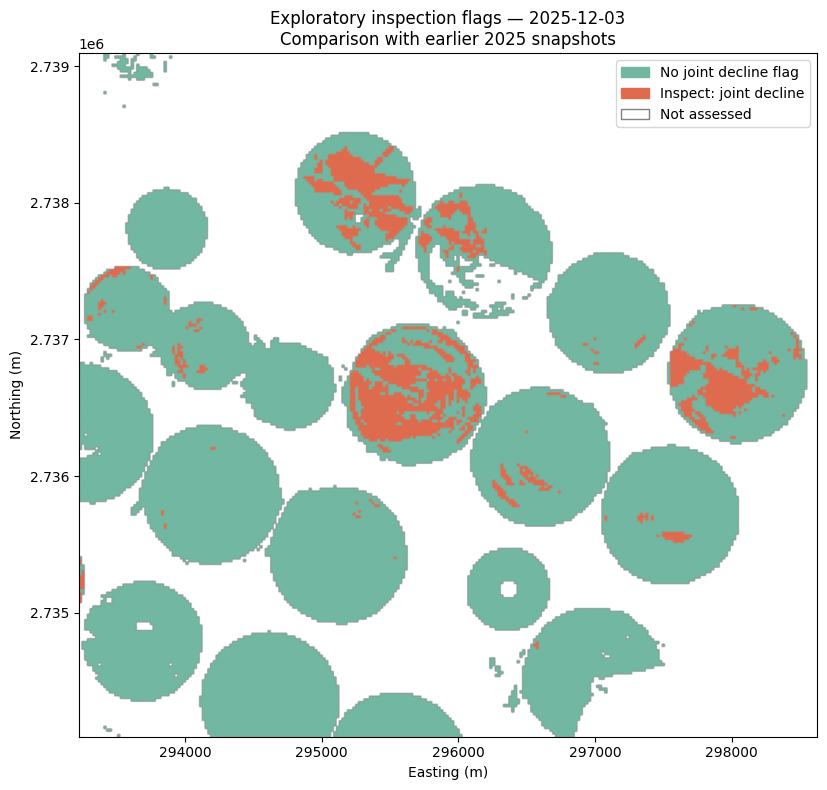

,joint_decline_threshold,flagged_area_ha,flagged_percent
0,0.05,245.28,22.628141
1,0.10,106.08,9.786339
2,0.15,32.08,2.959519


In [15]:
# CODE 12 — Flag joint greenness and moisture-index declines
assert globals().get("PROCESSING_COMPLETE", False), (
    "Code 07 did not finish successfully. "
    "Fix and rerun it before continuing."
)

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

if len(records) < MIN_OBSERVATIONS + 1:
    raise RuntimeError(
        "Need at least six earlier snapshots plus a latest snapshot."
    )
references = {}
reference_counts = {}
for name in ["NDVI", "NDMI"]:
    previous = stacks[name][:-1]
    reference_counts[name] = np.isfinite(previous).sum(axis=0)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        references[name] = np.nanmedian(previous, axis=0)
delta_ndvi = stacks["NDVI"][-1] - references["NDVI"]
delta_ndmi = stacks["NDMI"][-1] - references["NDMI"]
assessable = (
    vegetation_mask
    & (reference_counts["NDVI"] >= MIN_OBSERVATIONS)
    & (reference_counts["NDMI"] >= MIN_OBSERVATIONS)
    & np.isfinite(delta_ndvi) & np.isfinite(delta_ndmi)
)
if not assessable.any():
    raise RuntimeError("No pixels have enough valid reference observations.")
flagged = (
    assessable & (delta_ndvi <= -NDVI_DROP) & (delta_ndmi <= -NDMI_DROP)
)
flag_map = np.full((HEIGHT, WIDTH), np.nan, dtype="float32")
flag_map[assessable] = 0
flag_map[flagged] = 1
flagged_area = float(flagged.sum() * pixel_area_ha)
assessed_area = float(assessable.sum() * pixel_area_ha)
flagged_percent = 100 * flagged.sum() / assessable.sum()
print("Latest snapshot:", records[-1]["date"])
print("Assessed vegetation grid area:", round(assessed_area, 2), "ha")
print("Flagged grid area:", round(flagged_area, 2), "ha")
print("Flagged share of assessed area:", round(flagged_percent, 1), "%")
print("Flags indicate change for inspection, not confirmed water stress.")
fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(
    flag_map, extent=EXTENT,
    cmap=ListedColormap(["#72b7a1", "#df6b4f"]), vmin=0, vmax=1,
)
ax.legend(handles=[
    Patch(color="#72b7a1", label="No joint decline flag"),
    Patch(color="#df6b4f", label="Inspect: joint decline"),
    Patch(facecolor="white", edgecolor="gray", label="Not assessed"),
], loc="best")
ax.set_title(
    f"Exploratory inspection flags — {records[-1]['date']}\n"
    "Comparison with earlier 2025 snapshots"
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig(OUTPUT / "inspection_flags.png", dpi=180)
plt.show()
sensitivity_rows = []
for threshold in [0.05, 0.10, 0.15]:
    test_flags = (
        assessable & (delta_ndvi <= -threshold) & (delta_ndmi <= -threshold)
    )
    sensitivity_rows.append({
        "joint_decline_threshold": threshold,
        "flagged_area_ha": float(test_flags.sum() * pixel_area_ha),
        "flagged_percent": float(100 * test_flags.sum() / assessable.sum()),
    })
sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.to_csv(OUTPUT / "threshold_sensitivity.csv", index=False)
display(sensitivity)

Reading Landsat: LC09_L2SP_160043_20251202_02_T1
Valid study-area coverage: 99.8%


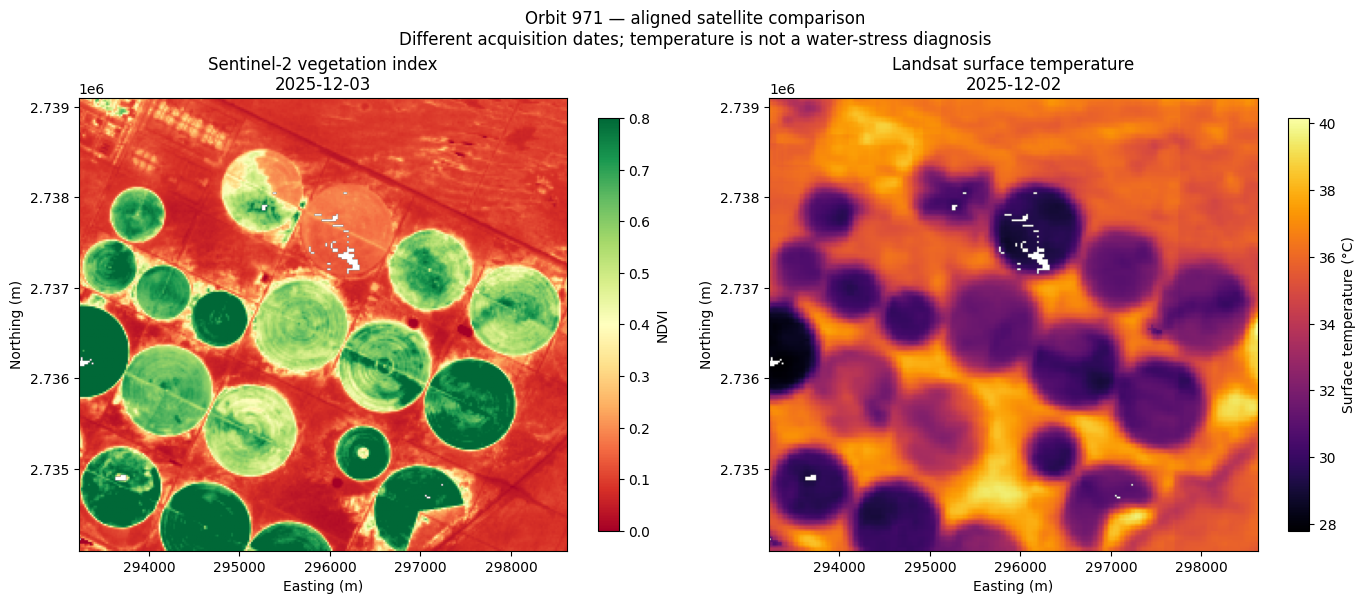


Landsat thermal processing completed.
Sentinel-2 date: 2025-12-03
Landsat date: 2025-12-02
Date gap: 1 day(s)
Saved temperature map and aligned comparison.
Original inspection flags have NOT been changed.


In [25]:
# CODE 13 — Read Landsat surface temperature and compare with Sentinel-2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import planetary_computer

from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling

LANDSAT_READY = False
landsat_result = None

required = [
    "landsat_items", "records", "GRID_CRS", "TRANSFORM",
    "WIDTH", "HEIGHT", "EXTENT", "OUTPUT"
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("Missing variables: " + ", ".join(missing))

if not globals().get("PROCESSING_COMPLETE", False):
    raise RuntimeError("Complete Code 07 successfully first.")

# Match the latest processed Sentinel-2 date.
target_record = records[-1]
target_date = pd.Timestamp(target_record["date"], tz="UTC")

MAX_GAP_DAYS = 8
MIN_VALID_FRACTION = 0.80

candidates = []
for item in landsat_items:
    if not all(
        key in item.assets
        for key in ["lwir11", "qa_pixel", "qa_radsat"]
    ):
        continue

    date = pd.to_datetime(item.datetime, utc=True)
    gap = abs((date.normalize() - target_date).days)

    if gap <= MAX_GAP_DAYS:
        candidates.append((gap, date, item))

candidates.sort(key=lambda row: (row[0], row[1]))

if not candidates:
    raise RuntimeError(
        "No Landsat scene with thermal and quality files "
        "within 8 days of the selected Sentinel-2 date."
    )


def read_landsat_band(item, key, quality=False):
    """Read one band onto the project grid using nearest neighbour."""
    asset = planetary_computer.sign(item.assets[key])

    # Zero is valid in some quality bands, so preserve it there.
    fill = 65535 if quality else 0

    with rasterio.Env(
        GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
        GDAL_HTTP_MAX_RETRY=2,
        GDAL_HTTP_RETRY_DELAY=2,
        GDAL_HTTP_TIMEOUT=60,
    ):
        with rasterio.open(asset.href) as src:
            with WarpedVRT(
                src,
                crs=GRID_CRS,
                transform=TRANSFORM,
                width=WIDTH,
                height=HEIGHT,
                src_nodata=None if quality else 0,
                nodata=fill,
                resampling=Resampling.nearest,
            ) as vrt:
                return vrt.read(1)


attempts = []

for gap, date, item in candidates:
    print("Reading Landsat:", item.id)

    try:
        raw_temperature = read_landsat_band(item, "lwir11")
        qa_pixel = read_landsat_band(
            item, "qa_pixel", quality=True
        ).astype("uint16")
        qa_radsat = read_landsat_band(
            item, "qa_radsat", quality=True
        ).astype("uint16")

        # QA_PIXEL bits 0–5:
        # fill, dilated cloud, cirrus, cloud, shadow, snow.
        clear = (qa_pixel & 0b111111) == 0

        # Also exclude medium/high cloud, shadow, snow
        # and cirrus confidence classifications.
        for shift in [8, 10, 12, 14]:
            confidence = (qa_pixel >> shift) & 0b11
            clear &= confidence < 2

        valid = (
            clear
            & (qa_radsat == 0)
            & np.isfinite(raw_temperature)
            & (raw_temperature > 0)
        )

        valid_fraction = float(valid.mean())
        attempts.append({
            "item_id": item.id,
            "date": date.strftime("%Y-%m-%d"),
            "gap_days": gap,
            "valid_fraction": valid_fraction,
            "status": "screened",
        })

        print(f"Valid study-area coverage: {valid_fraction:.1%}")

        if valid_fraction < MIN_VALID_FRACTION:
            print("Insufficient local coverage; trying next scene.")
            continue

        # USGS Landsat Collection 2 Level-2 ST:
        # stored value -> Kelvin -> degrees Celsius.
        temperature_c = (
            raw_temperature.astype("float32") * 0.00341802
            + 149.0
            - 273.15
        )
        temperature_c[~valid] = np.nan

        landsat_result = {
            "item_id": item.id,
            "date": date.strftime("%Y-%m-%d"),
            "gap_days": gap,
            "valid_fraction": valid_fraction,
            "temperature_c": temperature_c,
        }
        break

    except Exception as error:
        # Keep diagnostic messages short.
        message = str(error).split("?")[0][:200]
        print("Read failed:", type(error).__name__, message)
        attempts.append({
            "item_id": item.id,
            "date": date.strftime("%Y-%m-%d"),
            "gap_days": gap,
            "status": "read_failed",
            "error_type": type(error).__name__,
        })

pd.DataFrame(attempts).to_csv(
    OUTPUT / "landsat_thermal_read_checks.csv", index=False
)

if landsat_result is None:
    raise RuntimeError(
        "No usable thermal scene was read. "
        "Send the printed messages above; do not interpret a result yet."
    )

# Use the same valid locations in both displayed maps.
s2_ndvi = target_record["indices"]["NDVI"]
temperature_c = landsat_result["temperature_c"]

common = np.isfinite(s2_ndvi) & np.isfinite(temperature_c)

if not common.any():
    raise RuntimeError("No common valid coverage between the two images.")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im1 = axes[0].imshow(
    np.where(common, s2_ndvi, np.nan),
    extent=EXTENT, cmap="RdYlGn", vmin=0, vmax=0.8
)
axes[0].set_title(
    f"Sentinel-2 vegetation index\n{target_record['date']}"
)
fig.colorbar(im1, ax=axes[0], label="NDVI", shrink=0.8)

im2 = axes[1].imshow(
    np.where(common, temperature_c, np.nan),
    extent=EXTENT, cmap="inferno"
)
axes[1].set_title(
    f"Landsat surface temperature\n{landsat_result['date']}"
)
fig.colorbar(
    im2, ax=axes[1], label="Surface temperature (°C)", shrink=0.8
)

for ax in axes:
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

fig.suptitle(
    "Orbit 971 — aligned satellite comparison\n"
    "Different acquisition dates; temperature is not a water-stress diagnosis"
)
plt.tight_layout()
plt.savefig(
    OUTPUT / "sentinel_landsat_comparison.png", dpi=180
)
plt.show()

# Save the temperature values with their geographic coordinates.
with rasterio.open(
    OUTPUT / "landsat_surface_temperature_c.tif",
    "w",
    driver="GTiff",
    height=HEIGHT,
    width=WIDTH,
    count=1,
    dtype="float32",
    crs=GRID_CRS,
    transform=TRANSFORM,
    nodata=-9999.0,
    compress="deflate",
) as dst:
    dst.write(
        np.where(np.isfinite(temperature_c), temperature_c, -9999)
        .astype("float32"),
        1,
    )
    dst.update_tags(
        units="degrees Celsius",
        item_id=landsat_result["item_id"],
        acquisition_date=landsat_result["date"],
        note="Resampling to 20 m does not increase thermal detail.",
    )

pd.DataFrame([{
    "landsat_item_id": landsat_result["item_id"],
    "landsat_date": landsat_result["date"],
    "sentinel_date": target_record["date"],
    "date_gap_days": landsat_result["gap_days"],
    "valid_fraction": landsat_result["valid_fraction"],
    "status": "temperature_read_and_spatially_aligned",
    "used_in_original_inspection_flags": False,
}]).to_csv(OUTPUT / "landsat_thermal_pair.csv", index=False)

LANDSAT_READY = True

print("\nLandsat thermal processing completed.")
print("Sentinel-2 date:", target_record["date"])
print("Landsat date:", landsat_result["date"])
print("Date gap:", landsat_result["gap_days"], "day(s)")
print("Saved temperature map and aligned comparison.")
print("Original inspection flags have NOT been changed.")

## Code 14 — Export spatial results and documentation

In [16]:
# CODE 14— Export spatial results and documentation

assert globals().get("PROCESSING_COMPLETE", False), (
    "Code 07 did not finish successfully. "
    "Fix and rerun it before continuing."
)
def save_geotiff(filename, array):
    nodata = -9999.0
    output_array = np.where(
        np.isfinite(array), array, nodata
    ).astype("float32")
    with rasterio.open(
        OUTPUT / filename, "w", driver="GTiff",
        height=HEIGHT, width=WIDTH, count=1, dtype="float32",
        crs=GRID_CRS, transform=TRANSFORM, nodata=nodata, compress="deflate",
    ) as destination:
        destination.write(output_array, 1)

for name in stacks:
    save_geotiff(
        f"latest_{name.lower()}.tif",
        np.where(analysis_mask, stacks[name][-1], np.nan),
    )
save_geotiff("ndvi_change.tif", np.where(assessable, delta_ndvi, np.nan))
save_geotiff("ndmi_change.tif", np.where(assessable, delta_ndmi, np.nan))
save_geotiff("inspection_flags.tif", flag_map)
save_geotiff(
    "valid_observation_count.tif",
    np.where(analysis_mask, valid_count, np.nan),
)
collection = catalog.get_collection("sentinel-2-l2a")
manifest = {
    "project": PROJECT,
    "status": "Exploratory PoC; not field-validated",
    "centre_latitude": LATITUDE,
    "centre_longitude": LONGITUDE,
    "search_bbox": BBOX,
    "analysis_area_km2": grid_area_km2,
    "analysis_dimensions_m": [AREA_WIDTH_M, AREA_HEIGHT_M],
    "analysis_grid_bounds": [left, bottom, right, top],
    "analysed_mission": "Sentinel-2",
    "enmap_discovery": globals().get("enmap_status", {"status": "not_run", "used_in_analysis": False}),
    "landsat_status": "Availability inventory only; no thermal pixel analysis",
    "farm_boundary_supplied": FARM_GEOJSON is not None,
    "period": [START_DATE, END_DATE],
    "catalogue": "Microsoft Planetary Computer",
    "collection": "sentinel-2-l2a",
    "collection_license": collection.license,
    "collection_links": [
        {"rel": link.rel, "href": link.href}
        for link in collection.links if link.rel in ["license", "about"]
    ],
    "grid_crs": GRID_CRS,
    "resolution_m": RESOLUTION_M,
    "scene_cloud_filter_percent": MAX_SCENE_CLOUD,
    "minimum_local_clear_fraction": MIN_CLEAR_FRACTION,
    "vegetation_ndvi_threshold": VEGETATION_NDVI,
    "minimum_reference_observations": MIN_OBSERVATIONS,
    "ndvi_drop_threshold": NDVI_DROP,
    "ndmi_drop_threshold": NDMI_DROP,
    "selected_item_ids": [r["item_id"] for r in records],
    "selected_dates": [r["date"] for r in records],
    "screening_failure_count": len(screening_failures),
    "assessed_grid_area_ha": assessed_area,
    "flagged_grid_area_ha": flagged_area,
}
with open(OUTPUT / "project_manifest.json", "w") as file:
    json.dump(manifest, file, indent=2, default=str)
packages = [
    "pystac-client", "planetary-computer", "rasterio",
    "numpy", "scipy", "pandas", "matplotlib", "requests", "shapely",
]
versions = "\n".join(
    f"{package}=={importlib.metadata.version(package)}"
    for package in packages
)
(OUTPUT / "requirements_used.txt").write_text(versions)
readme = f"""
ORBIT 971 — AGRICULTURAL CHANGE MONITORING

Purpose
Identify vegetation areas with joint greenness and moisture-index
declines that may warrant field inspection.

Study period: {START_DATE} to {END_DATE}
Analysis rectangle: 5.4 km x 5 km = 27 km2 on the projected grid.
The geographic search BBOX encloses this analysis rectangle.
Optional Code 03B searches Landsat 8/9 availability only. No Landsat
temperature pixels are analysed and Landsat is not used in the flags.
Optional Code 03C inventories EnMAP hyperspectral L2A data. EnMAP pixels
are not downloaded or used in the flags. See enmap_status.json if run.
An EnMAP search failure means coverage is unknown, not absent.
Actual spectral analysis awaits suitable data and authorised access.

Data
Copernicus Sentinel-2 Level-2A via Microsoft Planetary Computer.
See project_manifest.json for licensing information and scene IDs.

Method
Search imagery; screen local SCL quality; select one eligible scene
per month; convert bands using metadata; align on a {RESOLUTION_M}-m
grid; calculate NDVI, NDRE, NDMI and BSI; compare the latest snapshot
with earlier-snapshot medians; flag joint declines for inspection.

Limitations
- Farm boundary supplied: {FARM_GEOJSON is not None}.
- A vegetation mask is not a crop-type or date-palm map.
- No field validation has been completed.
- Flags do not establish water stress or its cause.
- No irrigation amounts or water savings are estimated.
- Monthly snapshots are not monthly averages.
- Cloud classification can contain errors.
- The comparison is not seasonally matched.
- Thresholds are exploratory and require calibration.
- Mixed pixels may contain plants, soil and infrastructure.
- Vegetation masking can exclude severely degraded vegetation.
- Missing months and failed reads can bias coverage.
- Grid-cell hectares are not measured canopy area.
- No joint flag does not prove healthy crops.

Validation still needed
Confirm boundaries and crop type. Compare flagged and unflagged
locations with dated field observations, irrigation records or other
independent evidence. Test seasonality and threshold sensitivity.

Reproduction
Run Code 01–14 in order. Keep the notebook and any farm polygon.
selected_scenes.csv records chosen observations.
screening_failures.csv records failed reads.
Review the collection licence and attribution terms before submission.

Flag raster: 0 = no joint decline flag, 1 = inspection flag,
NoData = not assessed.
"""
(OUTPUT / "README.txt").write_text(readme.strip())
if FARM_GEOJSON is not None:
    shutil.copyfile(FARM_GEOJSON, OUTPUT / "farm_boundary.geojson")
print("Exported files:")
for path in sorted(OUTPUT.iterdir()):
    print("-", path.name)

Exported files:
- README.txt
- catalogue_results.csv
- enmap_candidate_assets.csv
- enmap_candidate_metadata.geojson
- enmap_coverage_inventory.csv
- enmap_status.json
- index_time_series.png
- inspection_flags.png
- inspection_flags.tif
- landsat_availability_only.csv
- latest_bsi.tif
- latest_index_maps.png
- latest_ndmi.tif
- latest_ndre.tif
- latest_ndvi.tif
- local_quality_checks.csv
- ndmi_change.tif
- ndvi_change.tif
- project_manifest.json
- requirements_used.txt
- screening_failures.csv
- selected_scenes.csv
- study_area_rgb.png
- threshold_sensitivity.csv
- valid_observation_count.tif
- vegetation_mask.png
- vegetation_time_series.csv


## Code 15 — Package and download results

In [17]:
# CODE 15 — Package and download results
assert globals().get("PROCESSING_COMPLETE", False), (
    "Code 07 did not finish successfully. "
    "Fix and rerun it before continuing."
)

from google.colab import files
archive_path = shutil.make_archive(
    "/content/Orbit_971_results_27km2", "zip", root_dir=OUTPUT,
)
print("Downloading:", archive_path)
files.download(archive_path)

Downloading: /content/Orbit_971_results_27km2.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>